# Stage 2 - v2: EfficientNet-B3 (Focal Loss & Class Weighting)

## 1. Giriş ve Problem Tanımı

Bu notebook, inme arter sınıflandırması projesinin **v2** iterasyonudur. 

### Önceki Deneyler ve Bulgular
*   **Baseline (v0):** MCA başarısı yüksek, ACA Recall %76.79.
*   **v1 (Smoothing):** Genel Accuracy %90.17'ye çıktı, MCA Recall %92.26 oldu. Ancak **ACA Recall %73.21'e düştü.**

**Analiz:**
Model, Label Smoothing ve Scheduler iyileştirmeleriyle genel doğruluğunu artırsa da, bunu çoğunluk sınıfını (MCA) daha iyi ezberleyerek yaptı. Azınlık sınıfı (ACA) üzerindeki baskı azaldığı için performans düştü. Model hala "kolay" örnekler üzerinden loss düşürüyor.

### v2 Stratejisi: Hard Example Mining
Bu versiyonda "yumuşak" yöntemleri bırakıp, dengesiz veri setleri için geliştirilmiş en etkili yöntem olan **Focal Loss**'a geçiyoruz.

1.  **Focal Loss:** Modelin zaten yüksek güvenle bildiği (easy positives - çoğunlukla MCA) örneklerin loss katkısını düşüreceğiz. Modelin odaklanması gereken yer "zor" ve "yanlış sınıflandırılan" örnekler (ACA) olacak.
2.  **Explicit Class Weighting:** Loss fonksiyonuna, sınıf frekanslarının tersiyle orantılı ağırlıklar (`alpha`) vereceğiz.
3.  **Label Smoothing İptal:** Focal Loss'un etkisini maksimize etmek için smoothing kaldırıldı.

## Bölüm 1: Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import models

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from tqdm import tqdm
from collections import Counter

# Seed Setting
SEED = 42
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

# Device Config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Bölüm 2: Sabitler ve Hiperparametreler

In [2]:
# --- PATHS ---
STROKE_IMAGES_DIR = '/kaggle/input/stroke-images/flattened_images'

# --- CLASS INFO ---
CLASS_NAMES = ['ACA', 'MCA', 'PCA']
NUM_CLASSES = len(CLASS_NAMES)

# --- HYPERPARAMETERS (v2) ---
IMG_SIZE = 300
BATCH_SIZE = 16
LEARNING_RATE = 1e-4 # Focal Loss bazen daha düşük LR ister ama şimdilik sabit tutuyoruz
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 100

# Focal Loss Parametreleri
GAMMA = 2.0  # Focusing parameter (Standart değer: 2.0)

# Scheduler (v1'den devam - iyi çalıştı)
T_0 = 10
T_MULT = 2

# Split Ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

print(f'=== Stage 2 - v2 Parametreleri ===')
print(f'Model: EfficientNet-B3')
print(f'Loss: FOCAL LOSS (Gamma={GAMMA}) + Class Weights')
print(f'Scheduler: CosineAnnealingWarmRestarts')
print(f'Checkpoint Metric: MACRO F1')

=== Stage 2 - v2 Parametreleri ===
Model: EfficientNet-B3
Loss: FOCAL LOSS (Gamma=2.0) + Class Weights
Scheduler: CosineAnnealingWarmRestarts
Checkpoint Metric: MACRO F1


## Bölüm 3: Veri Hazırlığı (Baseline ile Aynı)

In [3]:
def collect_stroke_image_paths(stroke_dir, class_names):
    image_paths = []
    labels = []
    for idx, class_name in enumerate(class_names):
        class_dir = Path(stroke_dir) / class_name
        if not class_dir.exists(): continue
        
        extensions = ['*.png', '*.jpg', '*.jpeg']
        class_images = []
        for ext in extensions:
            class_images.extend(list(class_dir.glob(ext)))
            
        for img_path in class_images:
            image_paths.append(str(img_path))
            labels.append(idx)
    return np.array(image_paths), np.array(labels)

all_image_paths, all_labels = collect_stroke_image_paths(STROKE_IMAGES_DIR, CLASS_NAMES)

# Stratified Split
X_temp, X_test, y_temp, y_test = train_test_split(
    all_image_paths, all_labels, test_size=TEST_RATIO, stratify=all_labels, random_state=SEED
)
val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio_adjusted, stratify=y_temp, random_state=SEED
)

## Bölüm 4: Augmentation & Dataset

In [4]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.ElasticTransform(alpha=50, sigma=50 * 0.05, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

class StrokeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = list(image_paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = int(self.labels[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        return image, label

train_dataset = StrokeDataset(X_train, y_train, transform=train_transform)
val_dataset = StrokeDataset(X_val, y_val, transform=val_transform)
test_dataset = StrokeDataset(X_test, y_test, transform=val_transform)

## Bölüm 5: WeightedRandomSampler & Class Weights Calculation

In [5]:
# 1. Sampler için ağırlıklar (Baseline ile aynı)
class_counts_train = Counter(y_train)
class_weights_sampler = {c: 1.0 / count for c, count in class_counts_train.items()}
sample_weights = [class_weights_sampler[int(label)] for label in y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# 2. Loss Fonksiyonu için Ağırlıklar (v2 Eklentisi)
# Formül: N_samples / (N_classes * N_samples_class)
total_samples = sum(class_counts_train.values())
class_weights_loss = []

print("\nLoss Fonksiyonu İçin Sınıf Ağırlıkları:")
for i in range(NUM_CLASSES):
    count = class_counts_train[i]
    weight = total_samples / (NUM_CLASSES * count)
    class_weights_loss.append(weight)
    print(f"  {CLASS_NAMES[i]}: {weight:.4f}")

# Tensor'a çevir ve GPU'ya at
class_weights_tensor = torch.FloatTensor(class_weights_loss).to(device)


Loss Fonksiyonu İçin Sınıf Ağırlıkları:
  ACA: 4.1346
  MCA: 0.4700
  PCA: 1.5855


## Bölüm 6: Focal Loss Implementasyonu (v2 ÖZEL)

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        Args:
            alpha (Tensor, optional): Sınıf ağırlıkları.
            gamma (float): Focusing parameter. Zor örneklere ne kadar odaklanılacağı.
            reduction (str): 'mean' veya 'sum'.
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Cross Entropy Loss (Log Softmax + NLL)
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        
        # P_t hesaplama (Modelin doğru sınıfa verdiği olasılık)
        pt = torch.exp(-ce_loss)
        
        # Focal Loss Formülü: (1 - pt)^gamma * CE
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print('Focal Loss sınıfı tanımlandı.')

Focal Loss sınıfı tanımlandı.


## Bölüm 7: Model, Loss ve Optimizer

In [7]:
# --- Model ---
def create_model(num_classes):
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(num_features, num_classes)
    )
    return model

model = create_model(NUM_CLASSES).to(device)

# --- Loss (v2: Focal Loss) ---
# Hem gamma=2.0 ile zor örneklere odaklanıyoruz
# Hem de alpha=class_weights_tensor ile azınlık sınıfına matematiksel ağırlık veriyoruz
criterion = FocalLoss(alpha=class_weights_tensor, gamma=GAMMA)

# --- Optimizer ---
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# --- Scheduler ---
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=T_0,
    T_mult=T_MULT,
    eta_min=1e-6
)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 171MB/s] 


## Bölüm 8: Eğitim Fonksiyonları (v1 ile Aynı - F1 Takibi)

In [8]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
    return running_loss / total, correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    avg_loss = running_loss / total
    accuracy = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    
    return avg_loss, accuracy, macro_f1, np.array(all_preds), np.array(all_labels)

## Bölüm 9: Eğitim Döngüsü

In [9]:
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0
CHECKPOINT_PATH = 'best_model_v2.pth'

print('Stage 2 - v2 Eğitimi Başlıyor (Focal Loss)...')

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, _, _ = validate(model, val_loader, criterion, device)
    
    scheduler.step(epoch)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | LR: {current_lr:.2e}')
    print(f'  Train Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%')
    print(f'  Val   Loss: {val_loss:.4f} | Acc: {val_acc*100:.2f}% | F1: {val_f1:.4f}')
    
    if val_f1 > best_val_f1:
        print(f'  >>> İyileşme! (F1: {best_val_f1:.4f} -> {val_f1:.4f}). Model kaydediliyor...')
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CHECKPOINT_PATH)
    
    print('-' * 60)

model.load_state_dict(torch.load(CHECKPOINT_PATH))
print(f'\nEğitim tamamlandı. En iyi model (Val F1: {best_val_f1:.4f}) yüklendi.')

Stage 2 - v2 Eğitimi Başlıyor (Focal Loss)...


Epoch 1/100 | LR: 1.00e-04
  Train Loss: 0.9726 | Acc: 41.92%
  Val   Loss: 0.5615 | Acc: 19.80% | F1: 0.2286
  >>> İyileşme! (F1: 0.0000 -> 0.2286). Model kaydediliyor...
------------------------------------------------------------


Epoch 2/100 | LR: 9.76e-05
  Train Loss: 0.6415 | Acc: 52.92%
  Val   Loss: 0.4264 | Acc: 22.83% | F1: 0.2511
  >>> İyileşme! (F1: 0.2286 -> 0.2511). Model kaydediliyor...
------------------------------------------------------------


Epoch 3/100 | LR: 9.05e-05
  Train Loss: 0.4897 | Acc: 57.46%
  Val   Loss: 0.4125 | Acc: 26.16% | F1: 0.2817
  >>> İyileşme! (F1: 0.2511 -> 0.2817). Model kaydediliyor...
------------------------------------------------------------


Epoch 4/100 | LR: 7.96e-05
  Train Loss: 0.4380 | Acc: 60.48%
  Val   Loss: 0.2581 | Acc: 39.88% | F1: 0.4026
  >>> İyileşme! (F1: 0.2817 -> 0.4026). Model kaydediliyor...
------------------------------------------------------------


...

Epoch 96/100 | LR: 7.80e-05
  Train Loss: 0.0610 | Acc: 89.68%
  Val   Loss: 0.3764 | Acc: 88.01% | F1: 0.8249
  >>> İyileşme! (F1: 0.8236 -> 0.8249). Model kaydediliyor...
------------------------------------------------------------


Epoch 97/100 | LR: 7.64e-05
  Train Loss: 0.0641 | Acc: 90.45%
  Val   Loss: 0.3165 | Acc: 85.69% | F1: 0.7978
------------------------------------------------------------


Epoch 98/100 | LR: 7.47e-05
  Train Loss: 0.0643 | Acc: 90.83%
  Val   Loss: 0.3486 | Acc: 86.71% | F1: 0.8059
------------------------------------------------------------


Epoch 99/100 | LR: 7.30e-05
  Train Loss: 0.0529 | Acc: 91.42%
  Val   Loss: 0.3312 | Acc: 88.15% | F1: 0.8215
------------------------------------------------------------


Epoch 100/100 | LR: 7.12e-05
  Train Loss: 0.0602 | Acc: 90.73%
  Val   Loss: 0.3646 | Acc: 86.42% | F1: 0.8114
------------------------------------------------------------

Eğitim tamamlandı. En iyi model (Val F1: 0.8249) yüklendi.


## Bölüm 10: Test ve Karşılaştırma

=== Stage 2 - v2 Test Değerlendirmesi ===
Test Accuracy: 88.29%
Test Macro F1: 0.8401

Classification Report:
              precision    recall  f1-score   support

         ACA     0.7231    0.8393    0.7769        56
         MCA     0.9726    0.8676    0.9171       491
         PCA     0.7302    0.9517    0.8263       145

    accuracy                         0.8829       692
   macro avg     0.8086    0.8862    0.8401       692
weighted avg     0.9016    0.8829    0.8867       692



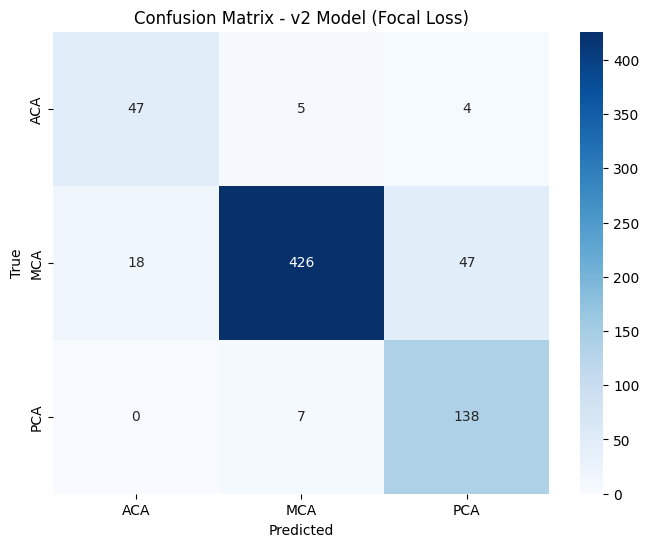


=== v2 vs v1 Karşılaştırması ===
Hedef ACA Recall: ≥ 0.85
v1 ACA Recall:    0.7321
v2 ACA Recall:    0.8393
✅ BAŞARILI: Focal Loss, ACA Recall değerini artırdı.


In [10]:
print('=== Stage 2 - v2 Test Değerlendirmesi ===')

test_loss, test_acc, test_f1, test_preds, test_labels = validate(model, test_loader, criterion, device)

print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test Macro F1: {test_f1:.4f}')

print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - v2 Model (Focal Loss)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

# --- Karşılaştırma ---
recall_per_class = recall_score(test_labels, test_preds, average=None)
aca_recall = recall_per_class[0]

print('\n=== v2 vs v1 Karşılaştırması ===')
print(f'Hedef ACA Recall: ≥ 0.85')
print(f'v1 ACA Recall:    0.7321')
print(f'v2 ACA Recall:    {aca_recall:.4f}')

if aca_recall > 0.7321:
    print('✅ BAŞARILI: Focal Loss, ACA Recall değerini artırdı.')
else:
    print('❌ BAŞARISIZ: Focal Loss da yeterli olmadı.')